# WSJ Headlines → S&P 500 Signal Feature Extraction

**Pipeline:**
1. Load & preprocess daily headline corpora
2. Extract keyword-count features from the signal map (12 categories)
3. Run general BERT sentiment (distilbert-base-uncased-finetuned-sst-2-english)
4. Run FinBERT sentiment (ProsusAI/finbert)
5. Export feature matrix ready for S&P 500 up/down classification

## 0 — Install Dependencies

In [ ]:
#!pip install transformers torch torchvision pandas numpy tqdm --quiet

# ── Verify MPS backend is available on this Mac ──────────────────
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'MPS built       : {torch.backends.mps.is_built()}')
print(f'MPS available   : {torch.backends.mps.is_available()}')
if not torch.backends.mps.is_available():
    print('⚠️  MPS not detected — will fall back to CPU.')
    print('    Make sure you are on macOS 12.3+ with PyTorch >= 2.0.')

PyTorch version : 2.9.1
MPS built       : True
MPS available   : True


## Load & Build Daily Corpora

In [31]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from tqdm import tqdm
tqdm.pandas()

# ── Load raw headlines ──────────────────────────────────────────────
raw = pd.read_csv('wsj_headlines.csv', encoding='utf-8')
raw['date'] = pd.to_datetime(raw['date'])
raw['headline'] = raw['headline'].astype(str).str.strip()

# One row per date: all headlines concatenated
daily = (
    raw.sort_values(['date', 'timestamp'])
    .groupby('date')['headline']
    .agg(lambda x: ' . '.join(x))
    .rename('corpus')
    .to_frame()
)
daily['corpus_lower'] = daily['corpus'].str.lower()

print(f'{len(raw):,} headlines → {len(daily)} daily corpora')
print(f'Date range: {daily.index.min().date()} → {daily.index.max().date()}')
daily.head(2)

292,196 headlines → 2992 daily corpora
Date range: 2018-01-01 → 2026-03-11


,corpus,corpus_lower
date,,
2018-01-01,Global Stock Surge Mints More Than $9 Trillion...,global stock surge mints more than $9 trillion...
2018-01-02,Pepper...and Salt . Who Are the Big Players in...,pepper...and salt . who are the big players in...


In [32]:
# ══════════════════════════════════════════════════════════════════════
# CORPUS SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════

# ── Basic tokenization (split on whitespace + strip punctuation) ──
def tokenize(text):
    """Lowercase, remove punctuation, split on whitespace."""
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
    return text.split()

# Tokenize all headlines (row-level for per-headline stats)
raw['tokens'] = raw['headline'].apply(tokenize)
raw['n_tokens'] = raw['tokens'].apply(len)

# Flatten all tokens
all_tokens = [tok for tokens in raw['tokens'] for tok in tokens]
word_freq = Counter(all_tokens)

# ── 1. Corpus-level stats ──
print('=' * 60)
print('CORPUS-LEVEL SUMMARY')
print('=' * 60)
print(f'Total headlines:           {len(raw):,}')
print(f'Total words (tokens):      {len(all_tokens):,}')
print(f'Unique words (vocabulary): {len(word_freq):,}')
print(f'Type-token ratio (TTR):    {len(word_freq) / len(all_tokens):.4f}')
print(f'Date range:                {raw["date"].min().date()} → {raw["date"].max().date()}')
print(f'Number of days:            {raw["date"].nunique():,}')

# ── 2. Per-headline stats ──
print('\n' + '=' * 60)
print('PER-HEADLINE STATISTICS')
print('=' * 60)
print(f'Mean words per headline:   {raw["n_tokens"].mean():.1f}')
print(f'Median words per headline: {raw["n_tokens"].median():.0f}')
print(f'Std words per headline:    {raw["n_tokens"].std():.1f}')
print(f'Min words per headline:    {raw["n_tokens"].min()}')
print(f'Max words per headline:    {raw["n_tokens"].max()}')

# ── 3. Per-day stats ──
daily_stats = raw.groupby('date').agg(
    headlines_per_day=('headline', 'count'),
    words_per_day=('n_tokens', 'sum'),
    avg_len_per_day=('n_tokens', 'mean')
)

print('\n' + '=' * 60)
print('PER-DAY STATISTICS')
print('=' * 60)
print(f'Mean headlines/day:        {daily_stats["headlines_per_day"].mean():.1f}')
print(f'Median headlines/day:      {daily_stats["headlines_per_day"].median():.0f}')
print(f'Min headlines/day:         {daily_stats["headlines_per_day"].min()}')
print(f'Max headlines/day:         {daily_stats["headlines_per_day"].max()}')
print(f'Mean words/day:            {daily_stats["words_per_day"].mean():.0f}')

# ── 4. Yearly breakdown ──
raw['year'] = raw['date'].dt.year
yearly = raw.groupby('year').agg(
    headlines=('headline', 'count'),
    total_words=('n_tokens', 'sum'),
    avg_headline_len=('n_tokens', 'mean'),
    unique_words=('tokens', lambda x: len(set(tok for toks in x for tok in toks)))
)

print('\n' + '=' * 60)
print('YEARLY BREAKDOWN')
print('=' * 60)
print(yearly.to_string())

# ── 5. Top 30 most frequent words ──
print('\n' + '=' * 60)
print('TOP 30 WORDS')
print('=' * 60)
for word, count in word_freq.most_common(30):
    print(f'  {word:<20s} {count:>7,}')

# ── 6. Hapax legomena (words appearing only once) ──
hapax = [w for w, c in word_freq.items() if c == 1]
print(f'\nHapax legomena (appear once): {len(hapax):,}  '
      f'({len(hapax)/len(word_freq)*100:.1f}% of vocabulary)')

# ── 7. Word length distribution ──
word_lengths = [len(tok) for tok in all_tokens]
print(f'\nMean word length:          {np.mean(word_lengths):.1f} chars')
print(f'Median word length:        {np.median(word_lengths):.0f} chars')

# ── 8. Save summary to CSV ──
summary = pd.DataFrame({
    'metric': [
        'total_headlines', 'total_words', 'unique_words', 'type_token_ratio',
        'num_days', 'mean_words_per_headline', 'median_words_per_headline',
        'mean_headlines_per_day', 'hapax_legomena', 'mean_word_length'
    ],
    'value': [
        len(raw), len(all_tokens), len(word_freq),
        round(len(word_freq) / len(all_tokens), 4),
        raw['date'].nunique(), round(raw['n_tokens'].mean(), 1),
        raw['n_tokens'].median(), round(daily_stats['headlines_per_day'].mean(), 1),
        len(hapax), round(np.mean(word_lengths), 1)
    ]
})
summary.to_csv('corpus_summary_stats.csv', index=False)
print('\nSaved: corpus_summary_stats.csv')

CORPUS-LEVEL SUMMARY
Total headlines:           292,196
Total words (tokens):      2,597,001
Unique words (vocabulary): 80,186
Type-token ratio (TTR):    0.0309
Date range:                2018-01-01 → 2026-03-11
Number of days:            2,992

PER-HEADLINE STATISTICS
Mean words per headline:   8.9
Median words per headline: 9
Std words per headline:    2.8
Min words per headline:    0
Max words per headline:    42

PER-DAY STATISTICS
Mean headlines/day:        97.7
Median headlines/day:      105
Min headlines/day:         15
Max headlines/day:         244
Mean words/day:            868

YEARLY BREAKDOWN
      headlines  total_words  avg_headline_len  unique_words
year                                                        
2018      50553       432267          8.550769         34450
2019      37281       316711          8.495239         27711
2020      37011       325403          8.792062         26630
2021      33077       297616          8.997672         26540
2022      34127      

## Signal Map Definition

Flattened from the topic-modelling-validated signal map.  
Each category → flat set of keyword phrases. Multi-word phrases are matched first (longest-match priority).

In [4]:
# ── SIGNAL MAP ───────────────────────────────────────────────────────
# All keywords lowercased; sets are flat (bullish/bearish/neutral merged
# into one count per category — sentiment is handled by BERT).

signal_map = {

    'TRADE_WAR': {
        'trade deal', 'tariff pause', 'reshoring', 'trade talks',
        'tariff', 'trade war', 'retaliatory', 'duties', 'ban', 'blacklist',
        'decoupling', 'sanctions', 'trade tensions', 'import tax', 'export controls',
        'tariff uncertainty', 'tariff hit', 'tariff threat', 'tariff threats',
        'tariff turmoil', 'tariff impact', 'tariff concerns', 'tariff deadline',
        'trade deficit', 'trade uncertainty',
    },

    'FED_POLICY': {
        'rate cut', 'dovish', 'pivot', 'easing', 'soft landing', 'pause',
        'rate cuts', 'cuts rates', 'rate cut hopes', 'holds rates', 'rates steady',
        'rate hike', 'hawkish', 'tightening', 'higher for longer', 'stagflation',
        'price hikes',
        'inflation', 'interest rate', 'quantitative',
        'federal reserve', 'fed chair', 'powell',
        'treasury yields', 'yields rise', 'yields fall',
        'inflation data', 'interest rates', 'fed minutes', 'fed independence',
        'ecb', 'central bank', 'mortgage rates', 'bond yields', 'jobless claims',
    },

    'FEAR_CRISIS': {
        'crash', 'recession', 'crisis', 'plunge', 'collapse', 'sell-off',
        'contagion', 'default', 'bank run', 'meltdown', 'bubble', 'shutdown',
        'tumble', 'plummet', 'panic', 'volatility',
        'stocks fall', 'shares plunge',
    },

    'EARNINGS': {
        'earnings beat', 'beat expectations', 'revenue beat', 'raised guidance',
        'blowout', 'upgrade', 'strong demand', 'sales growth', 'revenue growth',
        'earnings growth', 'earnings rise', 'lifts', 'raises',
        'earnings miss', 'missed expectations', 'revenue miss', 'lowered guidance',
        'profit warning', 'disappointed', 'downgrade', 'write-down', 'margin pressure',
        'cuts outlook', 'cut jobs', 'job cuts', 'cost cutting',
        'guidance', 'earnings season', 'outlook', 'forecast', 'eps',
        'after earnings', 'quarter', 'expects',
    },

    'EUPHORIA_MOMENTUM': {
        'surge', 'rally', 'boom', 'record high', 'all-time high', 'soar',
        'breakout', 'bull market', 'outperform', 'recovery', 'rebound', 'inflows',
        'shares surge', 'stocks rise', 'record', 'hopes', 'ai boom',
        'ai', 'deal', 'stock market', 'tech stocks',
    },

    'GEOPOLITICAL': {
        'ceasefire', 'peace talks', 'peace',
        'war', 'invasion', 'missile', 'drone', 'airstrike', 'nuclear',
        'strait of hormuz', 'houthi', 'red sea', 'regime change',
        'retaliation', 'escalation', 'proxy war', 'coup', 'intercept',
        'ukraine war', 'strikes', 'nato', 'military',
        'strike', 'debt ceiling', 'election',
        'ukraine', 'russia', 'putin', 'israel', 'gaza', 'iran',
    },

    'SECTOR_TRIGGER': {
        'fda approval', 'buyback', 'merger', 'acquisition', 'ipo',
        'billion buyback', 'share buyback', 'launches',
        'antitrust', 'data breach', 'bankruptcy', 'dividend cut', 'recall',
        'investigation', 'probe', 'files',
        'regulation', 'chip', 'm&a', 'drug',
    },

    'ENERGY_COMMODITY': {
        'oil spike', 'shortage',
        'opec', 'oil', 'production cut', 'gold', 'commodity', 'supply chain',
        'natural gas', 'pipeline', 'refinery', 'shipping', 'suez canal', 'copper',
        'oil futures', 'crude oil', 'crude', 'comex gold', 'gold settles',
        'oil prices', 'gas futures', 'oil stockpiles', 'gold futures',
        'russian oil', 'oil demand', 'oil and gas', 'gold rush', 'venezuela',
    },

    'LABOR_CONSUMER': {
        'hiring', 'consumer confidence', 'retail sales', 'wages',
        'consumer sentiment',
        'layoffs', 'unemployment', 'cost of living',
        'unemployment rate', 'federal workers',
        'jobs', 'housing', 'spending', 'strike', 'gdp', 'cpi', 'wegovy',
        'jobs report', 'jobs data', 'housing market', 'job market',
        'retail', 'economic growth',
    },

    'TRUMP_POLICY': {
        'deregulation', 'tax cut', 'infrastructure',
        'tax hike', 'indictment',
        'trump', 'maga', 'executive order', 'immigration', 'doge', 'tiktok', 'drill',
        'trump administration', 'trump tariffs', 'trump says', 'trump wants',
        'musk', 'trump threatens', 'trump signs', 'trump orders', 'trump announces',
        'blocks trump',
    },

    'CRYPTO_FINTECH': {
        'etf', 'bitcoin', 'crypto', 'blockchain', 'sec', 'stablecoin',
        'digital currency', 'meme stock', 'short squeeze', 'magnificent seven',
        'coinbase',
    },

    'AMPLIFIER_MOD': {
        'eases',
        'worst since', 'fears', 'concerns', 'deepens', 'unprecedented',
        'fears of', 'at risk', 'warns of', 'threat',
        'unexpected', 'surprise', 'biggest', 'historic',
        'despite', 'amid',
    },
}

print(f'Categories: {len(signal_map)}')
total_kw = sum(len(v) for v in signal_map.values())
print(f'Total unique keywords/phrases: {total_kw}')

Categories: 12
Total unique keywords/phrases: 284


## Keyword Feature Extraction (Longest-Match Counting)

For each category we:
1. Sort phrases by length descending (so "tariff uncertainty" matches before "tariff")
2. Count non-overlapping occurrences via `re.findall` with word boundaries
3. Store raw count per day per category

In [5]:
import re

def build_regex_patterns(signal_map):
    """
    For each category, compile a list of (pattern, phrase) tuples
    sorted longest-first so multi-word phrases match before substrings.
    """
    compiled = {}
    for cat, phrases in signal_map.items():
        # Sort longest first for greedy matching
        sorted_phrases = sorted(phrases, key=len, reverse=True)
        # Build ONE big alternation regex per category → much faster than N regexes
        escaped = [re.escape(p) for p in sorted_phrases]
        # Use word boundaries; for phrases with special chars like 'm&a', \b works on word chars
        pattern = re.compile(r'\b(?:' + '|'.join(escaped) + r')\b', re.IGNORECASE)
        compiled[cat] = pattern
    return compiled

patterns = build_regex_patterns(signal_map)

# ── Count matches per category per day ────────────────────────────
print('Extracting signal features...')
for cat, pat in tqdm(patterns.items(), desc='Categories'):
    daily[cat] = daily['corpus_lower'].apply(lambda txt: len(pat.findall(txt)))

feature_cols = list(signal_map.keys())
print(f'\nExtracted {len(feature_cols)} feature columns')
daily[feature_cols].describe().round(1)

Extracting signal features...


Categories: 100%|██████████| 12/12 [00:34<00:00,  2.85s/it]


Extracted 12 feature columns


,TRADE_WAR,FED_POLICY,FEAR_CRISIS,EARNINGS,EUPHORIA_MOMENTUM,GEOPOLITICAL,SECTOR_TRIGGER,ENERGY_COMMODITY,LABOR_CONSUMER,TRUMP_POLICY,CRYPTO_FINTECH,AMPLIFIER_MOD
count,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0,2992.0
mean,1.4,2.9,1.6,2.3,5.1,8.4,3.3,2.8,2.4,6.0,1.1,3.0
std,1.9,3.1,1.7,3.2,3.5,6.8,2.9,2.7,2.1,5.3,1.5,2.4
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,1.0,0.0,0.0,2.0,4.0,1.0,1.0,1.0,2.0,0.0,1.0
50%,1.0,2.0,1.0,1.0,5.0,7.0,3.0,2.0,2.0,5.0,1.0,3.0
75%,2.0,4.0,2.0,3.0,7.0,11.0,5.0,4.0,3.0,8.0,2.0,4.0
max,19.0,22.0,13.0,35.0,24.0,88.0,18.0,26.0,16.0,47.0,12.0,17.0


In [6]:
# ── Quick sanity check: top-5 days per category ──────────────────
for col in feature_cols:
    top = daily[col].nlargest(3)
    print(f'{col:25s}  max={top.iloc[0]:4d}  top3_dates: {list(top.index.strftime("%Y-%m-%d"))}')

TRADE_WAR                  max=  19  top3_dates: ['2025-04-15', '2025-04-10', '2025-04-09']
FED_POLICY                 max=  22  top3_dates: ['2018-03-08', '2025-07-16', '2022-02-10']
FEAR_CRISIS                max=  13  top3_dates: ['2020-03-09', '2020-03-12', '2018-02-06']
EARNINGS                   max=  35  top3_dates: ['2025-07-31', '2025-10-30', '2025-11-04']
EUPHORIA_MOMENTUM          max=  24  top3_dates: ['2025-01-29', '2025-07-23', '2025-11-05']
GEOPOLITICAL               max=  88  top3_dates: ['2022-02-24', '2022-03-02', '2022-02-28']
SECTOR_TRIGGER             max=  18  top3_dates: ['2018-09-06', '2018-12-06', '2018-05-01']
ENERGY_COMMODITY           max=  26  top3_dates: ['2026-01-05', '2026-01-07', '2026-01-08']
LABOR_CONSUMER             max=  16  top3_dates: ['2024-10-04', '2018-01-05', '2018-05-04']
TRUMP_POLICY               max=  47  top3_dates: ['2024-11-06', '2025-03-05', '2025-03-04']
CRYPTO_FINTECH             max=  12  top3_dates: ['2018-01-23', '2018-01-19', '2

## General BERT Sentiment (DistilBERT SST-2) — MPS Accelerated

We score each daily corpus using `distilbert-base-uncased-finetuned-sst-2-english`.  
Because corpora can be very long, we **chunk by headline** (split on ` . `), score each headline, then average.  
Output: `bert_sentiment` ∈ [-1, 1] where -1 = most negative, +1 = most positive.

**Apple M2 optimisation:** PyTorch MPS backend offloads tensor ops to the M2 GPU via Metal.  
Batch size bumped to 128 (unified memory means no CPU→GPU transfer bottleneck).  
Expected speedup vs CPU-only: **3-5×** on M2.

In [7]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# ── Apple Silicon M2: prefer MPS → CUDA → CPU ───────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')          # Metal Performance Shaders on M2
    DEVICE_ID = 'mps'
    print('✅ Using Apple M2 GPU via MPS')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    DEVICE_ID = 0
    print('✅ Using CUDA GPU')
else:
    DEVICE = torch.device('cpu')
    DEVICE_ID = -1
    print('⚠️  Falling back to CPU')

# ── General BERT sentiment ───────────────────────────────────────
# HuggingFace pipeline accepts 'mps' as device string since transformers ≥ 4.28
general_sent = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=DEVICE,
    truncation=True,
    max_length=512,
    batch_size=128,           # M2 unified memory handles larger batches well
)

def score_corpus_general(corpus_text):
    """
    Split daily corpus into individual headlines, score each,
    return mean sentiment in [-1, 1].
    """
    headlines = [h.strip() for h in corpus_text.split(' . ') if len(h.strip()) > 5]
    if not headlines:
        return 0.0
    # Truncate very long headlines to avoid token overflow
    headlines = [h[:500] for h in headlines]
    try:
        results = general_sent(headlines)
        scores = []
        for r in results:
            s = r['score'] if r['label'] == 'POSITIVE' else -r['score']
            scores.append(s)
        return np.mean(scores)
    except Exception as e:
        print(f'Error: {e}')
        return 0.0

print('Scoring general BERT sentiment (MPS accelerated)...')
daily['bert_sentiment'] = daily['corpus_lower'].progress_apply(score_corpus_general)
print(f'Done. Mean={daily["bert_sentiment"].mean():.4f}, Std={daily["bert_sentiment"].std():.4f}')

/Users/jishanahmed/Documents/DeepLearning/TestCodes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using Apple M2 GPU via MPS


Device set to use mps


Scoring general BERT sentiment (MPS accelerated)...


100%|██████████| 2992/2992 [24:53<00:00,  2.00it/s] 

Done. Mean=-0.2004, Std=0.1325


## Financial BERT Sentiment (FinBERT) — MPS Accelerated

ProsusAI/finbert is trained on financial text (news, 10-K filings).  
Labels: positive / negative / neutral → we map to a continuous score:  
`finbert_sentiment = P(positive) - P(negative)`  
Same MPS device and batch-size settings as Section 4.

In [8]:
# ── Financial BERT (FinBERT) — reuses DEVICE from cell above ───
finbert_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
finbert_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')

finbert_pipe = pipeline(
    'sentiment-analysis',
    model=finbert_model,
    tokenizer=finbert_tokenizer,
    device=DEVICE,
    truncation=True,
    max_length=512,
    batch_size=128,           # M2 unified memory handles larger batches well
    top_k=None,               # return all 3 class probabilities
)

def score_corpus_finbert(corpus_text):
    """
    Score each headline with FinBERT → continuous sentiment:
    finbert_score = P(positive) - P(negative)
    """
    headlines = [h.strip() for h in corpus_text.split(' . ') if len(h.strip()) > 5]
    if not headlines:
        return 0.0
    headlines = [h[:500] for h in headlines]
    try:
        results = finbert_pipe(headlines)
        scores = []
        for r in results:
            prob = {item['label']: item['score'] for item in r}
            score = prob.get('positive', 0) - prob.get('negative', 0)
            scores.append(score)
        return np.mean(scores)
    except Exception as e:
        print(f'Error: {e}')
        return 0.0

print('Scoring FinBERT sentiment (MPS accelerated)...')
daily['finbert_sentiment'] = daily['corpus_lower'].progress_apply(score_corpus_finbert)
print(f'Done. Mean={daily["finbert_sentiment"].mean():.4f}, Std={daily["finbert_sentiment"].std():.4f}')

Device set to use mps


Scoring FinBERT sentiment (MPS accelerated)...


100%|██████████| 2992/2992 [43:15<00:00,  1.15it/s] 

Done. Mean=-0.1195, Std=0.0629


## Feature Summary & Correlation Check

In [9]:
all_feature_cols = feature_cols + ['bert_sentiment', 'finbert_sentiment']

print('='*70)
print('FEATURE MATRIX SUMMARY')
print('='*70)
print(f'Shape: {daily.shape}')
print(f'Date range: {daily.index.min().date()} → {daily.index.max().date()}')
print(f'Feature columns ({len(all_feature_cols)}):')
for c in all_feature_cols:
    print(f'  {c:25s}  mean={daily[c].mean():8.2f}  std={daily[c].std():8.2f}  '
          f'min={daily[c].min():8.2f}  max={daily[c].max():8.2f}')
print()

# Pairwise correlation of signal features
corr = daily[all_feature_cols].corr()
print('Top 10 most correlated feature pairs:')
pairs = []
for i in range(len(all_feature_cols)):
    for j in range(i+1, len(all_feature_cols)):
        pairs.append((all_feature_cols[i], all_feature_cols[j],
                       corr.iloc[i, j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs[:10]:
    print(f'  {a:25s} × {b:25s}  r={r:+.3f}')

FEATURE MATRIX SUMMARY
Shape: (2992, 16)
Date range: 2018-01-01 → 2026-03-11
Feature columns (14):
  TRADE_WAR                  mean=    1.40  std=    1.93  min=    0.00  max=   19.00
  FED_POLICY                 mean=    2.92  std=    3.15  min=    0.00  max=   22.00
  FEAR_CRISIS                mean=    1.60  std=    1.74  min=    0.00  max=   13.00
  EARNINGS                   mean=    2.29  std=    3.16  min=    0.00  max=   35.00
  EUPHORIA_MOMENTUM          mean=    5.11  std=    3.54  min=    0.00  max=   24.00
  GEOPOLITICAL               mean=    8.35  std=    6.81  min=    0.00  max=   88.00
  SECTOR_TRIGGER             mean=    3.30  std=    2.88  min=    0.00  max=   18.00
  ENERGY_COMMODITY           mean=    2.76  std=    2.65  min=    0.00  max=   26.00
  LABOR_CONSUMER             mean=    2.40  std=    2.14  min=    0.00  max=   16.00
  TRUMP_POLICY               mean=    6.02  std=    5.33  min=    0.00  max=   47.00
  CRYPTO_FINTECH             mean=    1.13  std=   

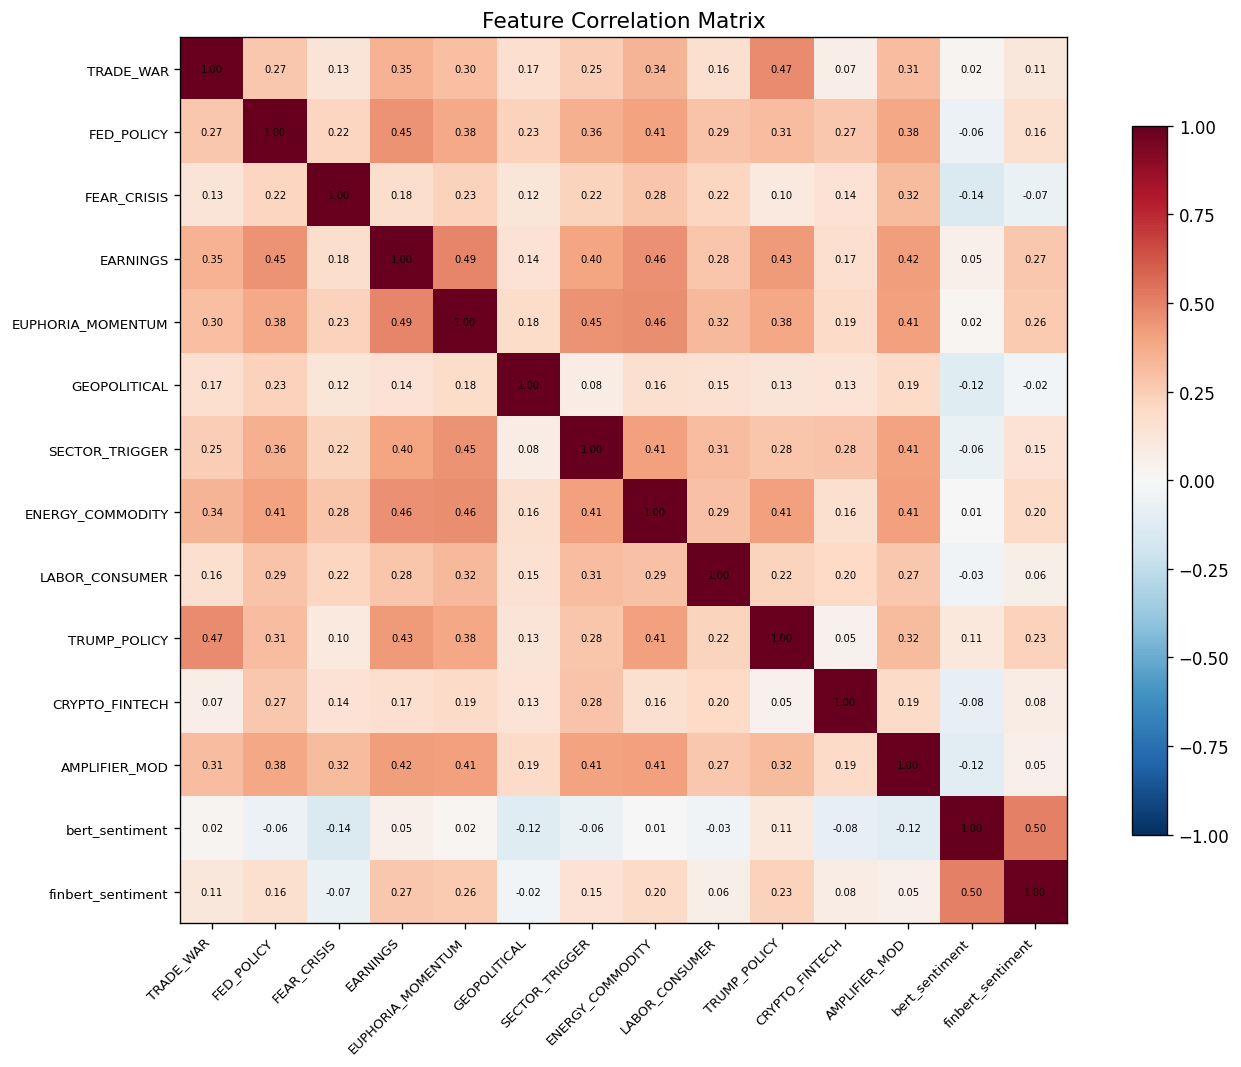

In [10]:
# ── Correlation heatmap ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(all_feature_cols)))
ax.set_yticks(range(len(all_feature_cols)))
ax.set_xticklabels(all_feature_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(all_feature_cols, fontsize=8)
for i in range(len(all_feature_cols)):
    for j in range(len(all_feature_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Export Feature Matrix

In [11]:
# ── Build final output dataframe ─────────────────────────────────
output_cols = ['corpus_lower'] + all_feature_cols
output = daily[output_cols].copy()
output.index.name = 'date'

# Save
output.to_csv('wsj_daily_features.csv')
print(f'Saved wsj_daily_features.csv  ({output.shape[0]} rows × {output.shape[1]} cols)')
output.head()

Saved wsj_daily_features.csv  (2992 rows × 15 cols)


,corpus_lower,TRADE_WAR,FED_POLICY,FEAR_CRISIS,EARNINGS,EUPHORIA_MOMENTUM,GEOPOLITICAL,SECTOR_TRIGGER,ENERGY_COMMODITY,LABOR_CONSUMER,TRUMP_POLICY,CRYPTO_FINTECH,AMPLIFIER_MOD,bert_sentiment,finbert_sentiment
date,,,,,,,,,,,,,,,
2018-01-01,global stock surge mints more than $9 trillion...,0,0,2,0,3,5,3,1,3,7,3,0,-0.150406,-0.071835
2018-01-02,pepper...and salt . who are the big players in...,0,8,0,10,7,7,10,9,1,2,6,9,-0.091583,-0.025952
2018-01-03,nasdaq crests 7000 as tech giants roar into 20...,1,12,2,9,11,9,11,7,3,9,8,12,-0.122814,-0.065202
2018-01-04,u.s. and south korea agree not to hold militar...,2,7,2,10,7,12,13,6,3,13,3,10,-0.095428,-0.077701
2018-01-05,30-minute recipe: roast lamb chops with brusse...,0,11,2,5,2,5,6,5,15,6,2,7,-0.228419,-0.038213


In [12]:
# ── Also save feature-only (no text) for quick model loading ─────
features_only = daily[all_feature_cols].copy()
features_only.index.name = 'date'
features_only.to_csv('wsj_features_only.csv')
print(f'Saved wsj_features_only.csv  ({features_only.shape[0]} rows × {features_only.shape[1]} cols)')
features_only.tail()

Saved wsj_features_only.csv  (2992 rows × 14 cols)


,TRADE_WAR,FED_POLICY,FEAR_CRISIS,EARNINGS,EUPHORIA_MOMENTUM,GEOPOLITICAL,SECTOR_TRIGGER,ENERGY_COMMODITY,LABOR_CONSUMER,TRUMP_POLICY,CRYPTO_FINTECH,AMPLIFIER_MOD,bert_sentiment,finbert_sentiment
date,,,,,,,,,,,,,,
2026-03-07,0,0,2,0,4,19,1,1,0,7,0,2,-0.218980,0.000038
2026-03-08,0,1,0,0,3,14,1,5,0,4,0,3,-0.177367,-0.043150
2026-03-09,1,3,1,3,6,33,2,11,2,16,0,2,-0.349416,-0.179859
2026-03-10,0,2,3,13,10,29,3,15,2,9,0,4,-0.175230,-0.079358
2026-03-11,0,3,0,6,7,5,1,6,1,0,0,4,-0.189338,0.288959


## Time-Series Visualization of Key Signals

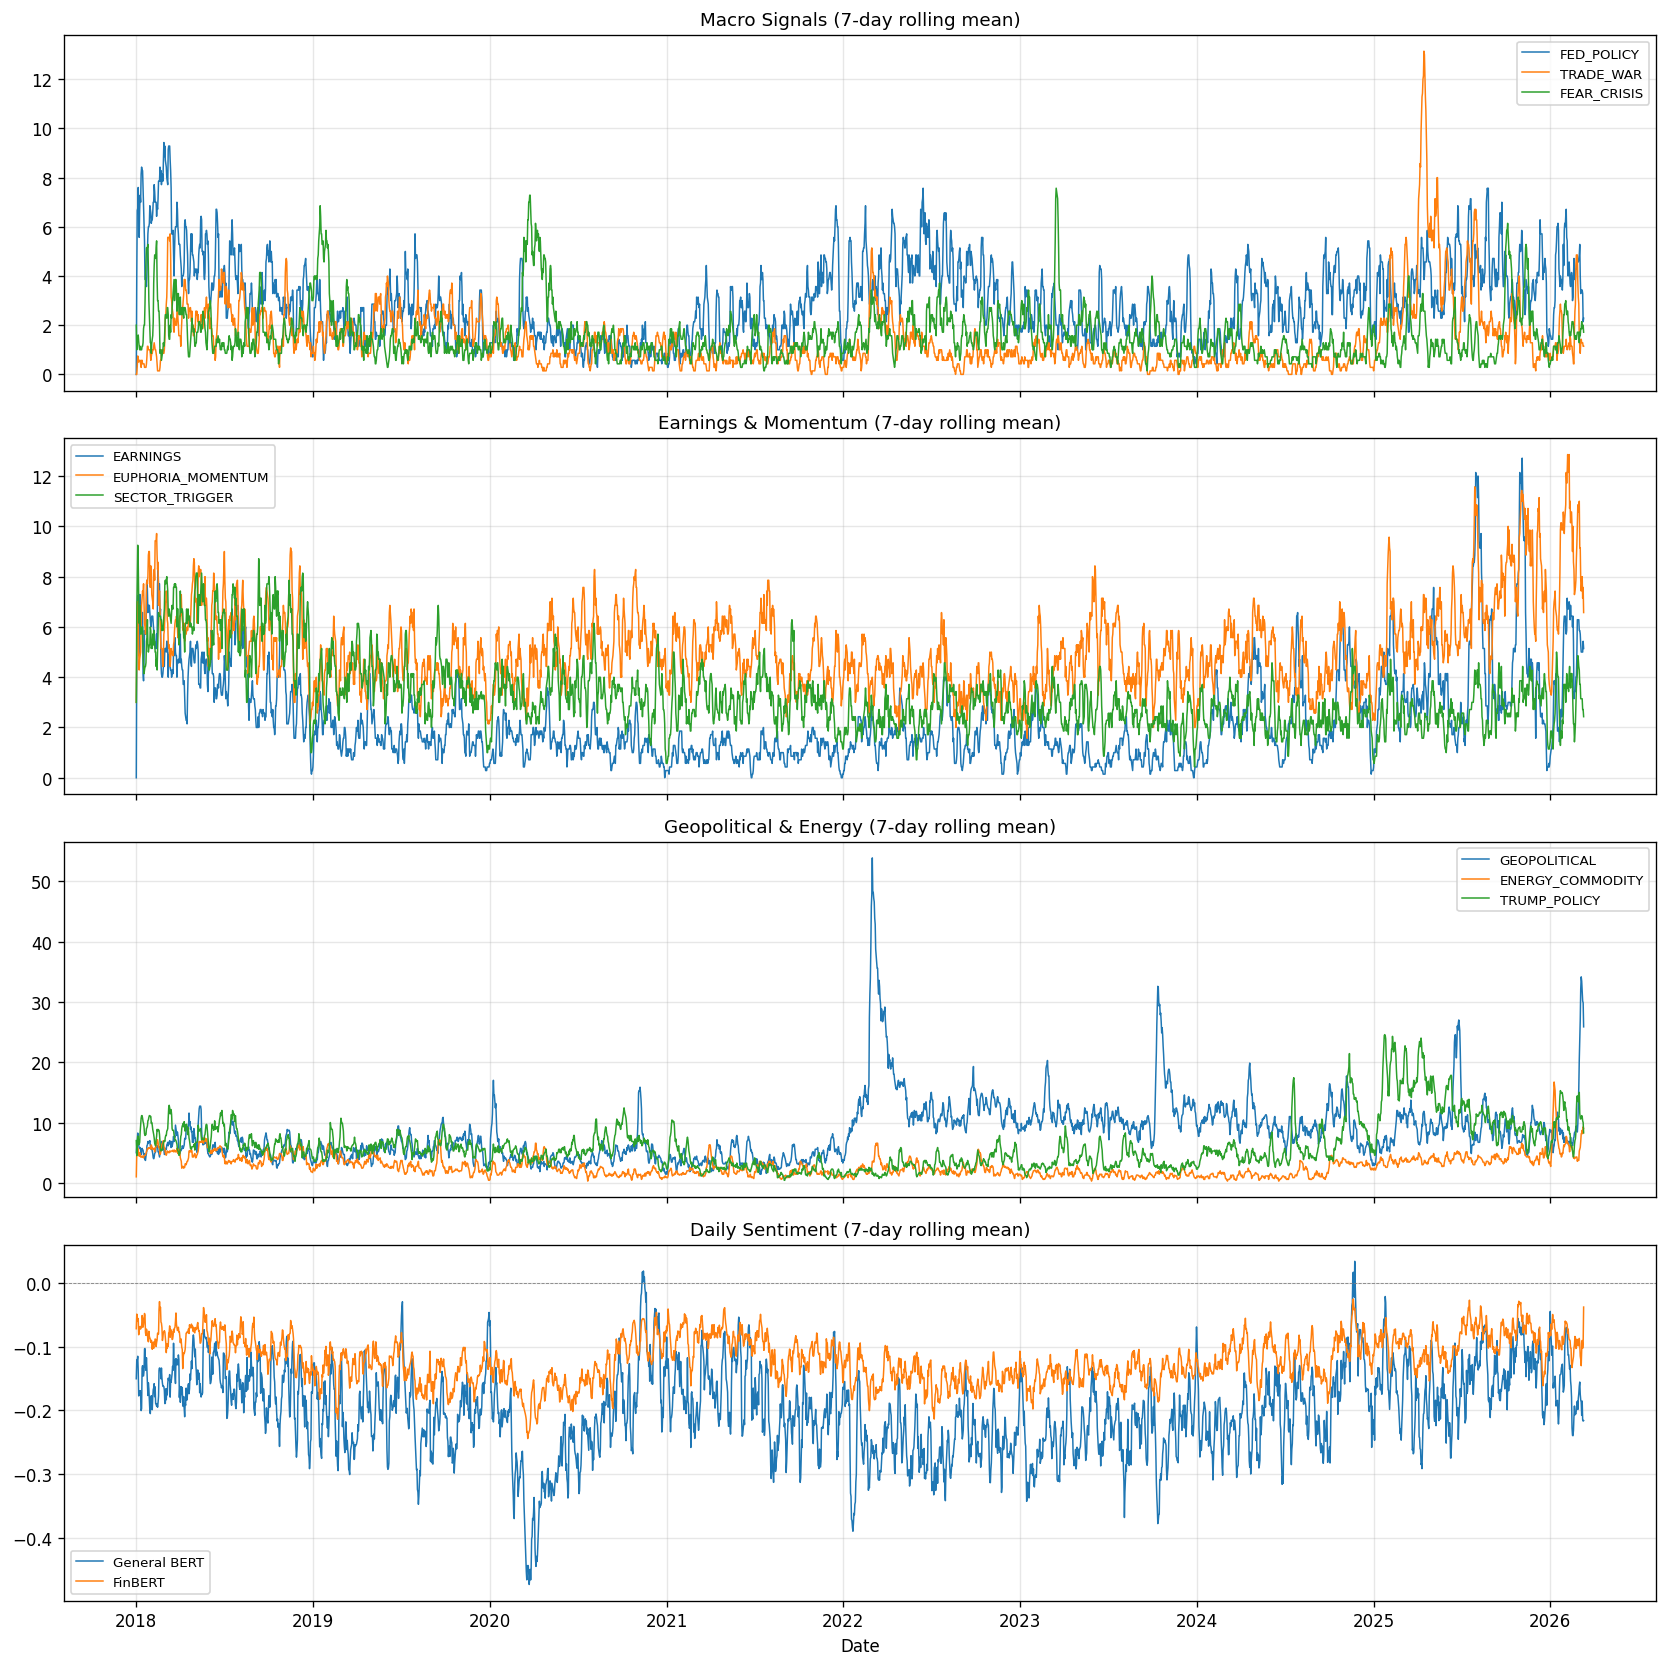

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# 7-day rolling average for readability
roll = daily[all_feature_cols].rolling(7, min_periods=1).mean()

# Panel 1: Macro signals
for col in ['FED_POLICY', 'TRADE_WAR', 'FEAR_CRISIS']:
    axes[0].plot(roll.index, roll[col], label=col, linewidth=0.9)
axes[0].set_title('Macro Signals (7-day rolling mean)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Panel 2: Earnings & Momentum
for col in ['EARNINGS', 'EUPHORIA_MOMENTUM', 'SECTOR_TRIGGER']:
    axes[1].plot(roll.index, roll[col], label=col, linewidth=0.9)
axes[1].set_title('Earnings & Momentum (7-day rolling mean)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Panel 3: Geopolitical & Energy
for col in ['GEOPOLITICAL', 'ENERGY_COMMODITY', 'TRUMP_POLICY']:
    axes[2].plot(roll.index, roll[col], label=col, linewidth=0.9)
axes[2].set_title('Geopolitical & Energy (7-day rolling mean)', fontsize=11)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

# Panel 4: Sentiment
axes[3].plot(roll.index, roll['bert_sentiment'], label='General BERT', linewidth=0.9)
axes[3].plot(roll.index, roll['finbert_sentiment'], label='FinBERT', linewidth=0.9)
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[3].set_title('Daily Sentiment (7-day rolling mean)', fontsize=11)
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [18]:
import yfinance as yf
import pandas as pd

START = "2018-01-01"
END   = "2026-03-12"   # end is exclusive

tickers = {
    "^GSPC": "sp500",
    "CL=F":  "oil",
    "^VIX":  "vix"
}

print("Downloading market data...")

frames = {}

for ticker, name in tickers.items():

    df = yf.download(
        ticker,
        start=START,
        end=END,
        progress=False,
        auto_adjust=False
    )

    if df.empty:
        raise ValueError(f"Download failed for {ticker}")

    # handle multi-index columns
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"][ticker]
    else:
        close = df["Close"]

    frames[name] = close.rename(f"{name}_close")

    print(f"{name:8s} ({ticker:6s}) : {len(df)} trading days")

# Merge datasets
market = pd.concat(frames.values(), axis=1)

market.index.name = "date"
market = market.sort_index()

# S&P500 returns
market["sp500_return"] = market["sp500_close"].pct_change()

market["direction"] = market["sp500_return"].apply(
    lambda x: "Up" if x > 0 else "Down"
)

market = market.dropna(subset=["sp500_return"])

market = market[
    ["sp500_close", "sp500_return", "direction", "oil_close", "vix_close"]
]

market.to_csv("market_data.csv", float_format="%.6f")

print("\nSaved: market_data.csv")
print(f"Rows: {len(market)} trading days")
print(f"Date range: {market.index.min().date()} → {market.index.max().date()}")

print("\nDirection counts:")
print(market["direction"].value_counts())

print("\nPreview:")
print(market.head(10))

sp500    (^GSPC ) : 2058 trading days
oil      (CL=F  ) : 2060 trading days
vix      (^VIX  ) : 2058 trading days

Saved: market_data.csv
Rows: 2059 trading days
Date range: 2018-01-03 → 2026-03-11

Direction counts:
direction
Up      1125
Down     934
Name: count, dtype: int64

Preview:
            sp500_close  sp500_return direction  oil_close  vix_close
date                                                                 
2018-01-03  2713.060059      0.006399        Up  61.630001       9.15
2018-01-04  2723.989990      0.004029        Up  62.009998       9.22
2018-01-05  2743.149902      0.007034        Up  61.439999       9.22
2018-01-08  2747.709961      0.001662        Up  61.730000       9.52
2018-01-09  2751.290039      0.001303        Up  62.959999      10.08
2018-01-10  2748.229980     -0.001112      Down  63.570000       9.82
2018-01-11  2767.560059      0.007034        Up  63.799999       9.88
2018-01-12  2786.239990      0.006750        Up  64.300003      10.16
2018-01-16 

/var/folders/6g/ml_vw8hx1k77xv81c6j4j5wm0000gq/T/ipykernel_2368/2600996950.py:47: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  market["sp500_return"] = market["sp500_close"].pct_change()


In [20]:
market.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2059 entries, 2018-01-03 to 2026-03-11
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sp500_close   2057 non-null   float64
 1   sp500_return  2059 non-null   float64
 2   direction     2059 non-null   object 
 3   oil_close     2059 non-null   float64
 4   vix_close     2057 non-null   float64
dtypes: float64(4), object(1)
memory usage: 96.5+ KB


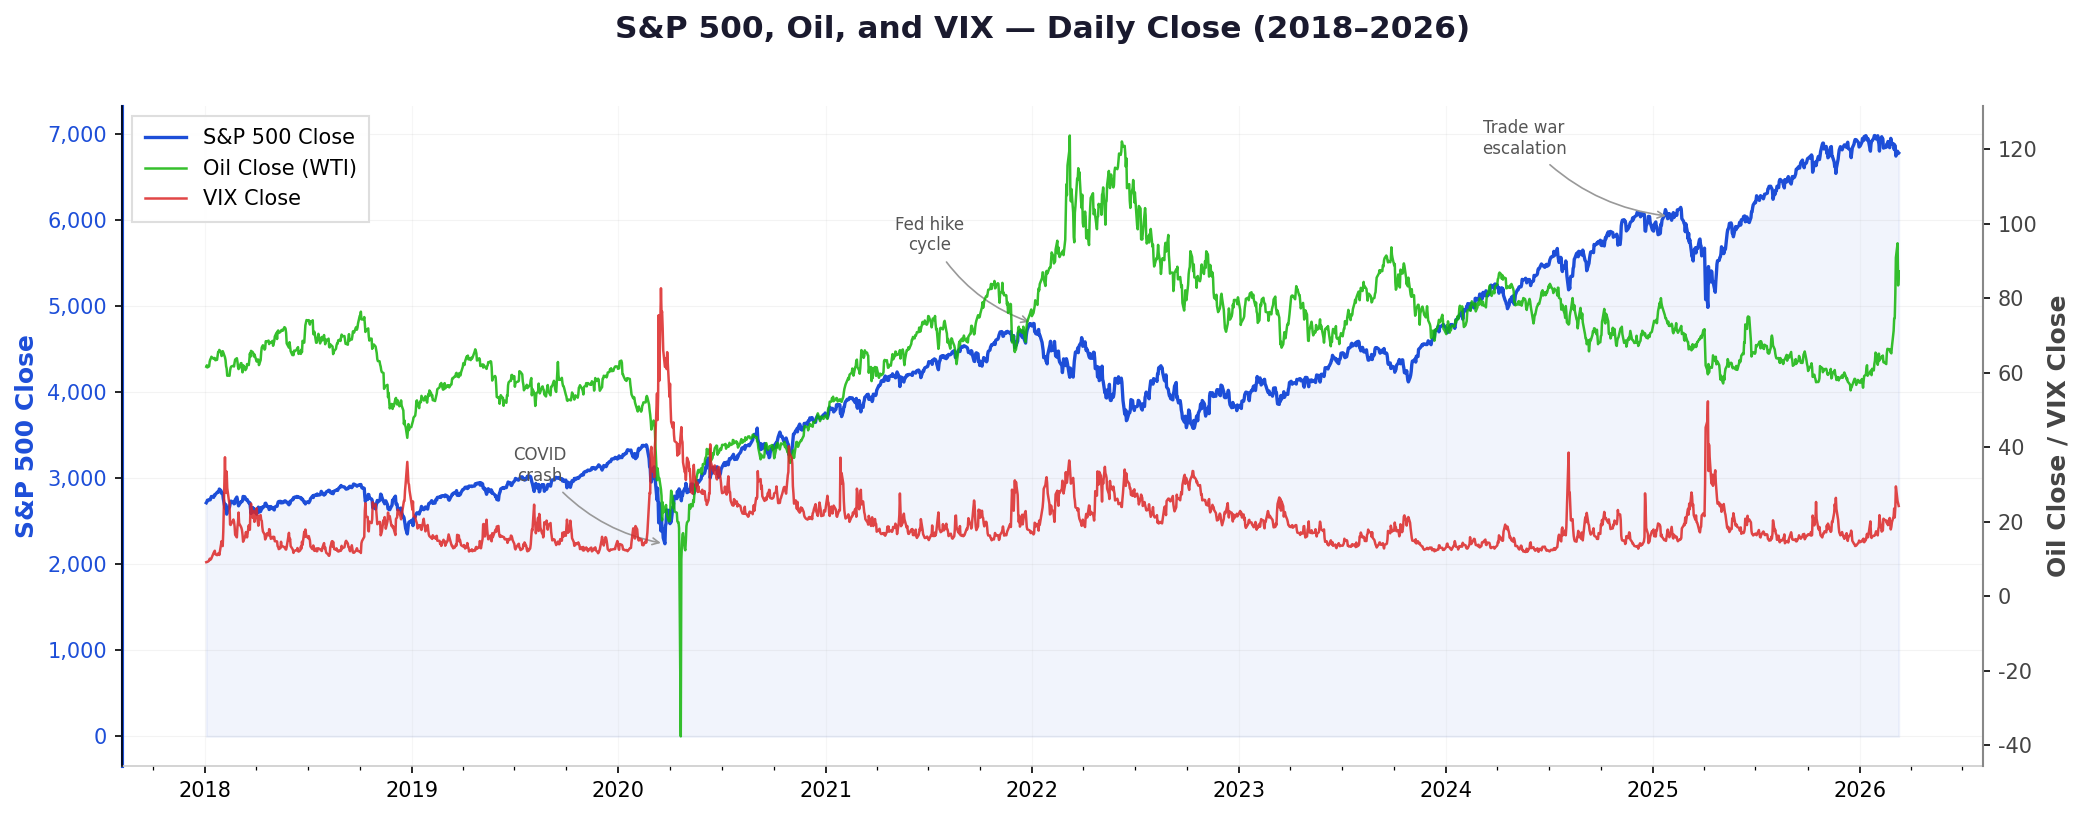

Saved: market_timeseries.png (300 dpi)


In [29]:
"""
Plot S&P 500 Close, Oil Close, and VIX Close with dual y-axes.
Requires: pandas, matplotlib
Usage:    python plot_market_data.py
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── Load data ──
df = pd.read_csv('market_data.csv', index_col=0, parse_dates=True)

# Drop NaN rows for clean plotting
df = df[['sp500_close', 'oil_close', 'vix_close']].dropna()

# ── Figure setup ──
fig, ax1 = plt.subplots(figsize=(14, 5.5), dpi=150)
ax2 = ax1.twinx()

# ── Colors ──
c_sp  = '#1D4ED8'   # blue — S&P 500
c_oil = "#13B508"   # amber — Oil
c_vix = '#DC2626'   # red — VIX

# ── Left axis: S&P 500 ──
ln1 = ax1.plot(df.index, df['sp500_close'], color=c_sp, linewidth=1.6,
               label='S&P 500 Close', zorder=3)

# ── Right axis: Oil & VIX ──
ln2 = ax2.plot(df.index, df['oil_close'], color=c_oil, linewidth=1.2,
               label='Oil Close (WTI)', alpha=0.85, zorder=2)
ln3 = ax2.plot(df.index, df['vix_close'], color=c_vix, linewidth=1.2,
               label='VIX Close', alpha=0.85, zorder=2)

# ── Light shading under S&P 500 ──
ax1.fill_between(df.index, df['sp500_close'], alpha=0.06, color=c_sp)

# ── Axis labels ──
ax1.set_ylabel('S&P 500 Close', fontsize=12, fontweight='600', color=c_sp)
ax2.set_ylabel('Oil Close / VIX Close', fontsize=12, fontweight='600', color='#444')

# ── Tick colors ──
ax1.tick_params(axis='y', labelcolor=c_sp, labelsize=10)
ax2.tick_params(axis='y', labelcolor='#444', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)

# ── Format y-axes ──
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

# ── X-axis formatting ──
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# ── Grid (subtle, left axis only) ──
ax1.grid(True, axis='y', alpha=0.15, linewidth=0.5)
ax1.grid(True, axis='x', alpha=0.10, linewidth=0.5)
ax2.grid(False)

# ── Spines ──
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.spines['left'].set_color(c_sp)
ax1.spines['left'].set_linewidth(1.5)
ax2.spines['right'].set_color('#888')
ax2.spines['right'].set_linewidth(1.0)
ax1.spines['bottom'].set_color('#ccc')
ax2.spines['bottom'].set_visible(False)

# ── Combined legend ──
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=10, frameon=True,
           fancybox=False, edgecolor='#ddd', facecolor='#fff',
           framealpha=0.95, borderpad=0.6)

# ── Title ──
fig.suptitle('S&P 500, Oil, and VIX — Daily Close (2018–2026)',
             fontsize=15, fontweight='700', color='#1a1a2e', y=0.98)

# ── Key events annotation (optional — remove if not wanted) ──
events = [
    ('2020-03-23', 'COVID\ncrash',   -60, 30),
    ('2022-01-03', 'Fed hike\ncycle', -50, 35),
    ('2025-02-01', 'Trade war\nescalation', -70, 30),
]
for date_str, label, xoff, yoff in events:
    date = pd.Timestamp(date_str)
    if date in df.index:
        val = df.loc[date, 'sp500_close']
    else:
        nearest = df.index[df.index.get_indexer([date], method='nearest')[0]]
        val = df.loc[nearest, 'sp500_close']
        date = nearest
    ax1.annotate(label, xy=(date, val), fontsize=8, color='#555',
                 fontweight='500', ha='center',
                 xytext=(xoff, yoff), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='#999',
                                 lw=0.8, connectionstyle='arc3,rad=0.2'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('market_timeseries.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: market_timeseries.png (300 dpi)')

In [22]:
market.index = pd.to_datetime(market.index)

print('── Market DataFrame ──')
print(f'Shape: {market.shape}')
print(f'Date range: {market.index.min().date()} → {market.index.max().date()}')
print(f'Columns: {list(market.columns)}')
print(f'Direction value counts:\n{market["direction"].value_counts()}')
print()
market.info()
market.head(3)

── Market DataFrame ──
Shape: (2059, 5)
Date range: 2018-01-03 → 2026-03-11
Columns: ['sp500_close', 'sp500_return', 'direction', 'oil_close', 'vix_close']
Direction value counts:
direction
Up      1125
Down     934
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2059 entries, 2018-01-03 to 2026-03-11
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sp500_close   2057 non-null   float64
 1   sp500_return  2059 non-null   float64
 2   direction     2059 non-null   object 
 3   oil_close     2059 non-null   float64
 4   vix_close     2057 non-null   float64
dtypes: float64(4), object(1)
memory usage: 96.5+ KB


,sp500_close,sp500_return,direction,oil_close,vix_close
date,,,,,
2018-01-03,2713.060059,0.006399,Up,61.630001,9.15
2018-01-04,2723.989990,0.004029,Up,62.009998,9.22
2018-01-05,2743.149902,0.007034,Up,61.439999,9.22


In [23]:
# ── Inner join: features_only × market on date ───────────────────
# features_only has 2992 rows (every calendar day incl. weekends)
# market has 2059 rows (trading days only)
# Inner join keeps only trading days with headline data.

merged = features_only.join(market, how='inner')

print('── Merged Dataset ──')
print(f'features_only rows  : {len(features_only):,}')
print(f'market rows         : {len(market):,}')
print(f'merged rows (inner) : {len(merged):,}')
print(f'Date range          : {merged.index.min().date()} → {merged.index.max().date()}')
print(f'Columns ({len(merged.columns)}): {list(merged.columns)}')
print()

# ── Check for any trading days lost in the join ──────────────────
lost_market = market.index.difference(features_only.index)
lost_features = features_only.index.difference(market.index)
print(f'Market dates NOT in features : {len(lost_market)}')
print(f'Feature dates NOT in market  : {len(lost_features)}  (weekends/holidays — expected)')
if len(lost_market) > 0:
    print(f'  ⚠️  Missing headline dates: {sorted(lost_market.strftime("%Y-%m-%d"))[:10]}...')
print()

# ── Null check ───────────────────────────────────────────────────
nulls = merged.isnull().sum()
if nulls.any():
    print('Null counts:')
    print(nulls[nulls > 0])
else:
    print('✅ No nulls in merged dataset')

merged.head(5)

── Merged Dataset ──
features_only rows  : 2,992
market rows         : 2,059
merged rows (inner) : 2,059
Date range          : 2018-01-03 → 2026-03-11
Columns (19): ['TRADE_WAR', 'FED_POLICY', 'FEAR_CRISIS', 'EARNINGS', 'EUPHORIA_MOMENTUM', 'GEOPOLITICAL', 'SECTOR_TRIGGER', 'ENERGY_COMMODITY', 'LABOR_CONSUMER', 'TRUMP_POLICY', 'CRYPTO_FINTECH', 'AMPLIFIER_MOD', 'bert_sentiment', 'finbert_sentiment', 'sp500_close', 'sp500_return', 'direction', 'oil_close', 'vix_close']

Market dates NOT in features : 0
Feature dates NOT in market  : 933  (weekends/holidays — expected)

Null counts:
sp500_close    2
vix_close      2
dtype: int64


,TRADE_WAR,FED_POLICY,FEAR_CRISIS,EARNINGS,EUPHORIA_MOMENTUM,GEOPOLITICAL,SECTOR_TRIGGER,ENERGY_COMMODITY,LABOR_CONSUMER,TRUMP_POLICY,CRYPTO_FINTECH,AMPLIFIER_MOD,bert_sentiment,finbert_sentiment,sp500_close,sp500_return,direction,oil_close,vix_close
date,,,,,,,,,,,,,,,,,,,
2018-01-03,1,12,2,9,11,9,11,7,3,9,8,12,-0.122814,-0.065202,2713.060059,0.006399,Up,61.630001,9.15
2018-01-04,2,7,2,10,7,12,13,6,3,13,3,10,-0.095428,-0.077701,2723.989990,0.004029,Up,62.009998,9.22
2018-01-05,0,11,2,5,2,5,6,5,15,6,2,7,-0.228419,-0.038213,2743.149902,0.007034,Up,61.439999,9.22
2018-01-08,0,8,1,17,6,5,8,5,3,9,1,10,-0.141664,-0.027135,2747.709961,0.001662,Up,61.730000,9.52
2018-01-09,0,12,1,10,8,8,7,6,4,14,1,4,-0.064072,-0.050855,2751.290039,0.001303,Up,62.959999,10.08


In [24]:
# ── Direction target summary ─────────────────────────────────────
print('Target distribution:')
print(merged['direction'].value_counts())
print()
print(f'Up ratio   : {(merged["direction"] == "Up").mean():.3f}')
print(f'Down ratio : {(merged["direction"] == "Down").mean():.3f}')

# ── Encode direction as binary for modelling ─────────────────────
merged['target'] = (merged['direction'] == 'Up').astype(int)
print(f'\nBinary target (1=Up, 0=Down):\n{merged["target"].value_counts()}')

Target distribution:
direction
Up      1125
Down     934
Name: count, dtype: int64

Up ratio   : 0.546
Down ratio : 0.454

Binary target (1=Up, 0=Down):
target
1    1125
0     934
Name: count, dtype: int64


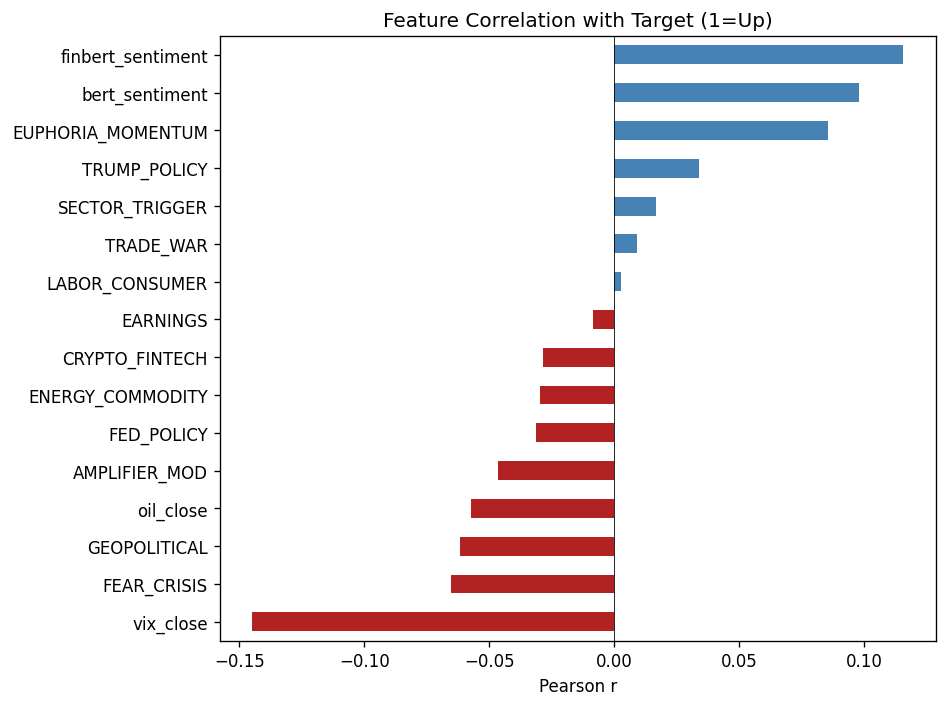


Top 5 positive correlations with Up days:
  finbert_sentiment          r = +0.1158
  bert_sentiment             r = +0.0981
  EUPHORIA_MOMENTUM          r = +0.0856
  TRUMP_POLICY               r = +0.0338
  SECTOR_TRIGGER             r = +0.0167

Top 5 negative correlations (predict Down):
  vix_close                  r = -0.1448
  FEAR_CRISIS                r = -0.0652
  GEOPOLITICAL               r = -0.0616
  oil_close                  r = -0.0571
  AMPLIFIER_MOD              r = -0.0466


In [25]:
# ── Feature-vs-target correlation ────────────────────────────────
model_features = all_feature_cols + ['oil_close', 'vix_close']

corr_target = merged[model_features + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot.barh(ax=ax, color=['firebrick' if v < 0 else 'steelblue' for v in corr_target])
ax.set_title('Feature Correlation with Target (1=Up)', fontsize=12)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print('\nTop 5 positive correlations with Up days:')
for feat, r in corr_target.nlargest(5).items():
    print(f'  {feat:25s}  r = {r:+.4f}')
print('\nTop 5 negative correlations (predict Down):')
for feat, r in corr_target.nsmallest(5).items():
    print(f'  {feat:25s}  r = {r:+.4f}')

In [26]:
# ── Save final merged dataset ────────────────────────────────────
merged.index.name = 'date'
merged.to_csv('wsj_market_features.csv')
print(f'Saved wsj_market_features.csv  ({merged.shape[0]} rows × {merged.shape[1]} cols)')
print(f'\nFinal columns:')
for i, c in enumerate(merged.columns):
    dtype = merged[c].dtype
    print(f'  {i:2d}. {c:25s}  {str(dtype):10s}  nulls={merged[c].isnull().sum()}')
print(f'\n✅ Dataset ready for classification.')
merged.tail(5)

Saved wsj_market_features.csv  (2059 rows × 20 cols)

Final columns:
   0. TRADE_WAR                  int64       nulls=0
   1. FED_POLICY                 int64       nulls=0
   2. FEAR_CRISIS                int64       nulls=0
   3. EARNINGS                   int64       nulls=0
   4. EUPHORIA_MOMENTUM          int64       nulls=0
   5. GEOPOLITICAL               int64       nulls=0
   6. SECTOR_TRIGGER             int64       nulls=0
   7. ENERGY_COMMODITY           int64       nulls=0
   8. LABOR_CONSUMER             int64       nulls=0
   9. TRUMP_POLICY               int64       nulls=0
  10. CRYPTO_FINTECH             int64       nulls=0
  11. AMPLIFIER_MOD              int64       nulls=0
  12. bert_sentiment             float64     nulls=0
  13. finbert_sentiment          float64     nulls=0
  14. sp500_close                float64     nulls=2
  15. sp500_return               float64     nulls=0
  16. direction                  object      nulls=0
  17. oil_close               

,TRADE_WAR,FED_POLICY,FEAR_CRISIS,EARNINGS,EUPHORIA_MOMENTUM,GEOPOLITICAL,SECTOR_TRIGGER,ENERGY_COMMODITY,LABOR_CONSUMER,TRUMP_POLICY,CRYPTO_FINTECH,AMPLIFIER_MOD,bert_sentiment,finbert_sentiment,sp500_close,sp500_return,direction,oil_close,vix_close,target
date,,,,,,,,,,,,,,,,,,,,
2026-03-05,4,4,4,12,8,48,3,11,4,9,3,11,-0.232886,-0.105795,6830.709961,-0.005647,Down,81.010002,23.75,0
2026-03-06,3,3,2,2,8,33,6,14,7,13,0,4,-0.169313,-0.145515,6740.020020,-0.013277,Down,90.900002,29.49,0
2026-03-09,1,3,1,3,6,33,2,11,2,16,0,2,-0.349416,-0.179859,6795.990234,0.008304,Up,94.769997,25.50,1
2026-03-10,0,2,3,13,10,29,3,15,2,9,0,4,-0.175230,-0.079358,6781.479980,-0.002135,Down,83.449997,24.93,0
2026-03-11,0,3,0,6,7,5,1,6,1,0,0,4,-0.189338,0.288959,6775.799805,-0.000838,Down,87.250000,24.23,0
